# **Optical data Analysis**
Control vs Polymer — per DIV and magnification

In [6]:
# IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy import stats
import os
import glob
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from sklearn.cluster import DBSCAN
from skimage.measure import regionprops_table
import tifffile

In [ ]:
#  PARAMETERS

BASE_DIR = r"C:/Users/vicki/OneDrive - Universite de Liege/TFE/Analysis/Pictures"      

PARAMS = {
    '20x': {'um_by_px': 1/4.93, 'image_width': 3840, 'image_height': 2160},
    '40x': {'um_by_px': 1/9.78, 'image_width': 3840, 'image_height': 2160},
}

# Radii for connectivity analysis (µm)
RADIUS_UM = [20, 40, 60, 80, 100, 120] # to be adjusted according to neurite lengths (20 to 120 µm)
NEURITE_LENGTH_UM = {
    'DIV1': 30,   
    'DIV2': 60,
    'DIV3': 100,
}

In [8]:
# PARAMETERS EXTRACTION FROM FOLDERS ORGANIZATION 
# BASE_DIR/Culture_X/Control_or_pPPY/2_Cellpose_Segmentation/260311_DIV2_Slip1_20x_somas_centroids.csv
#BASE_DIR/Culture_X/Control_or_pPPY/2_Cellpose_Segmentation/260311_DIV2_Slip1_20x_mask_somas.tif

csv_files = glob.glob(
    os.path.join(BASE_DIR, '**', '2_Cellpose_Segmentation', '*.csv'),
    recursive=True
)
print(f"{len(csv_files)} CSVs found\n")

results = []

for csv_path in csv_files:
    parts = csv_path.replace('\\', '/').split('/')

    try:
        seg_idx = parts.index('2_Cellpose_Segmentation')
        type = parts[seg_idx - 1]
        culture = parts[seg_idx - 2]
    except (ValueError, IndexError):
        print(f"Structure not recognized : {csv_path}")
        continue

    filename = os.path.basename(csv_path).lower()

    div = 'unknown'
    slip = 'unknown'
    zoom = 'unknown'
    for part in filename.replace('.csv', '').split('_'):
        if part.startswith('div'):
            div = part.upper() 
        elif part.startswith('slip'):
            slip = part.upper()
        elif '10x' in part or '20x' in part or '40x' in part:
            zoom = part.lower()

    mask_filename = os.path.basename(csv_path).replace('_somas_centroids.csv', '_mask_somas.tif')
    mask_path = os.path.join(os.path.dirname(csv_path), mask_filename)
    

    results.append({
        'culture': culture,
        'type': type,
        'div': div,
        'slip': slip,
        'zoom': zoom,
        'csv_path': csv_path,
        'mask_path': mask_path,
        'mask_exists': os.path.exists(mask_path)  # to check if the mask file exists
    })

df_data = pd.DataFrame(results)
df_data = df_data[df_data['culture'] == 'Culture2'].copy()   #ONLY CULTURE 2
print(f"\n{len(df_data)} files processed")
df_data

28 CSVs found


27 files processed


,culture,type,div,slip,zoom,csv_path,mask_path,mask_exists
1,Culture2,Control,DIV1,SLIP1,20x,C:/Users/vicki/OneDrive - Universite de Liege/...,C:/Users/vicki/OneDrive - Universite de Liege/...,True
2,Culture2,Control,DIV1,SLIP2,20x,C:/Users/vicki/OneDrive - Universite de Liege/...,C:/Users/vicki/OneDrive - Universite de Liege/...,True
3,Culture2,Control,DIV1,SLIP3,20x,C:/Users/vicki/OneDrive - Universite de Liege/...,C:/Users/vicki/OneDrive - Universite de Liege/...,True
4,Culture2,Control,DIV1,SLIP4,20x,C:/Users/vicki/OneDrive - Universite de Liege/...,C:/Users/vicki/OneDrive - Universite de Liege/...,True
5,Culture2,Control,DIV1,SLIP5,20x,C:/Users/vicki/OneDrive - Universite de Liege/...,C:/Users/vicki/OneDrive - Universite de Liege/...,True
6,Culture2,Control,DIV2,SLIP1,20x,C:/Users/vicki/OneDrive - Universite de Liege/...,C:/Users/vicki/OneDrive - Universite de Liege/...,True
7,Culture2,Control,DIV2,SLIP2,20x,C:/Users/vicki/OneDrive - Universite de Liege/...,C:/Users/vicki/OneDrive - Universite de Liege/...,True
8,Culture2,Control,DIV2,SLIP3,20x,C:/Users/vicki/OneDrive - Universite de Liege/...,C:/Users/vicki/OneDrive - Universite de Liege/...,True
9,Culture2,Control,DIV2,SLIP4,20x,C:/Users/vicki/OneDrive - Universite de Liege/...,C:/Users/vicki/OneDrive - Universite de Liege/...,True
10,Culture2,Control,DIV2,SLIP5,20x,C:/Users/vicki/OneDrive - Universite de Liege/...,C:/Users/vicki/OneDrive - Universite de Liege/...,True


In [ ]:
print(f"{df_data['mask_exists'].sum()} / {len(df_data)} masks found")
df_data[~df_data['mask_exists']]  # show files without mask

27 / 27 masques trouvés


,culture,type,div,slip,zoom,csv_path,mask_path,mask_exists


# Spatial arrangement + Morpholoy Anlysis

In [10]:
results_list = []

for _, row in df_data.iterrows():
    p = PARAMS[row['zoom']]
    um = p['um_by_px']
    area_um2 = p['image_width'] * p['image_height'] * (um ** 2)

    df = pd.read_csv(row['csv_path'])

    # -------- RATIO NEURON/GLIAL --------------------------------------
    somas_total = len(df)
    n_somas = len(df[df['status'] == 'somas'])
    n_glia = len(df[df['status'] == 'glials'])
    ratio_neuron_glial = (n_somas / somas_total) * 100 if somas_total > 0 else np.nan

    # -------- DENSITY --------------------------------------------------
    df = df[df['status'] == 'somas'].copy()
    n_somas = len(df)
    density = n_somas / area_um2 * 1e6

    # -------- NND & CLARK-EVANS & CONNECTIVITY & DBSCAN ----------------
    nnd_mean = nnd_median = clark_evans_r = np.nan
    n_clusters = mean_cluster_size = frac_isolated = np.nan
    neighbours_results = {f'mean_neighbours_R{R}': np.nan for R in RADIUS_UM}

    if n_somas >= 2:
        coords = df[['x', 'y']].values * um
        tree = KDTree(coords)

        distances, _ = tree.query(coords, k=2)
        nnd_um = distances[:, 1]
        nnd_mean = round(nnd_um.mean(), 2)
        nnd_median = round(np.median(nnd_um), 2)

        density_um2 = n_somas / area_um2
        if density_um2 > 0:
            r_expected = 1 / (2 * np.sqrt(density_um2))
            clark_evans_r = round(nnd_mean / r_expected, 3)

        for R_um in RADIUS_UM:
            idx = tree.query_ball_point(coords, R_um)
            counts = [len(i) - 1 for i in idx]
            neighbours_results[f'mean_neighbours_R{R_um}'] = round(np.mean(counts), 2)

        eps_um = NEURITE_LENGTH_UM.get(row['div'], 70)
        min_samples = 4

        db = DBSCAN(eps=eps_um, min_samples=min_samples).fit(coords)
        labels = db.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 0:
            cluster_sizes = pd.Series(labels[labels != -1]).value_counts()
            mean_cluster_size = round(cluster_sizes.mean(), 2)
        frac_isolated = round(np.mean(labels == -1), 3)

    # -------- MORPHOLOGY (masks) -------------------------------------
    mean_area_um2 = mean_circularity = mean_solidity = mean_aspect_ratio = confluence_pct = np.nan

    if row['mask_exists']:
        masks = tifffile.imread(row['mask_path'])
        props = regionprops_table(masks, properties=[
            'label', 'centroid', 'area', 'perimeter',
            'eccentricity', 'solidity',
            'major_axis_length', 'minor_axis_length'
        ])
        df_morph = pd.DataFrame(props)

        if len(df_morph) > 0:
            df_morph['area_um2'] = df_morph['area'] * (um ** 2)
            df_morph['aspect_ratio'] = df_morph['major_axis_length'] / df_morph['minor_axis_length']
            df_morph['circularity'] = np.where(
                df_morph['perimeter'] > 0,
                4 * np.pi * df_morph['area'] / (df_morph['perimeter'] ** 2),
                np.nan
            )
            mean_area_um2 = round(df_morph['area_um2'].mean(), 2)
            mean_circularity = round(df_morph['circularity'].mean(), 3)
            mean_solidity = round(df_morph['solidity'].mean(), 3)
            mean_aspect_ratio = round(df_morph['aspect_ratio'].mean(), 2)
            confluence_pct = round(df_morph['area_um2'].sum() / area_um2 * 100, 2)

    results_list.append({
        'culture': row['culture'], 'type': row['type'], 'div': row['div'],
        'slip': row['slip'], 'zoom': row['zoom'],
        'n_neurons': n_somas, 'n_glial': n_glia, 'ratio_neuron_glial': ratio_neuron_glial,
        'density': density, 'nnd_mean': nnd_mean, 'nnd_median': nnd_median,
        'clark_evans_r': clark_evans_r,
        'n_clusters': n_clusters, 'mean_cluster_size': mean_cluster_size, 'frac_isolated': frac_isolated,
        **neighbours_results,
        'mean_area_um2': mean_area_um2, 'mean_circularity': mean_circularity,
        'mean_solidity': mean_solidity, 'mean_aspect_ratio': mean_aspect_ratio,
        'confluence_pct': confluence_pct,
    })

df_results = pd.DataFrame(results_list)

In [11]:
# Save all results
output_path = os.path.join(BASE_DIR, 'results_summary_updated.csv')
df_results.to_csv(output_path, index=False)
print(f"Results saved : {output_path}")
df_results

Results saved : C:/Users/vicki/OneDrive - Universite de Liege/TFE/Analysis/Pictures\results_summary_updated.csv


,culture,type,div,slip,zoom,n_neurons,n_glial,ratio_neuron_glial,density,nnd_mean,...,mean_neighbours_R40,mean_neighbours_R60,mean_neighbours_R80,mean_neighbours_R100,mean_neighbours_R120,mean_area_um2,mean_circularity,mean_solidity,mean_aspect_ratio,confluence_pct
0,Culture2,Control,DIV1,SLIP1,20x,153,71,68.303571,448.332574,21.71,...,2.94,5.69,9.16,14.04,19.33,134.24,0.835,0.960,1.36,6.02
1,Culture2,Control,DIV1,SLIP2,20x,128,55,69.945355,375.075617,24.18,...,2.20,4.55,7.45,11.16,15.31,127.82,0.817,0.949,1.47,4.79
2,Culture2,Control,DIV1,SLIP3,20x,131,100,56.709957,383.866452,25.34,...,1.98,4.09,7.28,10.84,15.01,131.72,0.839,0.954,1.37,5.06
3,Culture2,Control,DIV1,SLIP4,20x,381,90,80.891720,1116.436017,16.29,...,5.62,11.57,19.97,29.83,41.14,106.90,0.844,0.963,1.36,11.94
4,Culture2,Control,DIV1,SLIP5,20x,984,124,88.808664,2883.393808,11.24,...,13.91,30.14,50.98,76.59,106.74,93.11,0.847,0.965,1.31,26.85
5,Culture2,Control,DIV2,SLIP1,20x,402,147,73.224044,1177.971861,15.69,...,7.07,14.40,23.36,33.97,46.39,112.94,0.794,0.943,1.44,13.30
6,Culture2,Control,DIV2,SLIP2,20x,149,116,56.226415,436.611461,24.83,...,2.47,4.87,8.23,12.31,17.26,118.40,0.808,0.948,1.43,5.17
7,Culture2,Control,DIV2,SLIP3,20x,379,140,73.025048,1110.575461,16.17,...,5.57,12.43,20.94,30.96,42.46,104.26,0.833,0.955,1.34,11.58
8,Culture2,Control,DIV2,SLIP4,20x,466,85,84.573503,1365.509669,14.81,...,6.88,14.82,25.39,37.95,52.52,98.66,0.861,0.969,1.26,13.47
9,Culture2,Control,DIV2,SLIP5,20x,381,92,80.549683,1116.436017,16.20,...,5.43,11.63,20.13,30.57,42.16,103.85,0.838,0.956,1.32,11.59


# Statistics (pPPY vs Control)

In [ ]:
# # Statistics (pPPY vs Control) - Welch's t-test with Cohen's d

# %%
from scipy.stats import ttest_ind 

METRICS_TO_TEST = [
    ("Density (cells/mm2)", "density"),
    ("Neurons/Glials ratio", "ratio_neuron_glial"),
    ("Clark-Evans (Clustering)", "clark_evans_r"),
    ("NND mean (µm)", "nnd_mean"),
    ("NND median (µm)", "nnd_median"),
    *[(f"Neighbours R={R}µm", f"mean_neighbours_R{R}") for R in RADIUS_UM],
    ("N clusters (DBSCAN)", "n_clusters"),
    ("Mean cluster size", "mean_cluster_size"),
    ("Isolated fraction", "frac_isolated"),
    ("Confluence (%)", "confluence_pct"),
    ("Mean area (µm²)", "mean_area_um2"),
    ("Mean circularity", "mean_circularity"),
    ("Mean solidity", "mean_solidity"),
    ("Mean aspect ratio", "mean_aspect_ratio"),
]

def calculate_cohen_d(group1, group2):
    """Calculate Cohen's d effect size for two independent samples."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    if pooled_std == 0:
        return 0.0
    return (np.mean(group2) - np.mean(group1)) / pooled_std

def run_stat(name, ctrl_data, poly_data):
    c = ctrl_data.dropna()
    p = poly_data.dropna()

    if len(c) < 2 or len(p) < 2:
        print(f" {name:<28} | Not enough data to compare")
        return

    mean_c = c.mean()
    mean_p = p.mean()
    diff = ((mean_p - mean_c) / mean_c * 100) if mean_c != 0 else np.nan

    # If both groups have exactly the same values (e.g., all in 1 cluster)
    if c.std() == 0 and p.std() == 0 and mean_c == mean_p:
        print(f" {name:<28} | {mean_c:>10.2f} | {mean_p:>10.2f} | {0.0:>+8.1f}% | 1.0000 (ns) |  0.00 (Identical)")
        return

    # Welch's t-test
    stat, p_val = ttest_ind(c, p, equal_var=False)
    sig = "(*)" if p_val < 0.05 else "(ns)"
    
    # Cohen's d
    d = calculate_cohen_d(c, p)
    
    # Qualify effect magnitude
    abs_d = abs(d)
    d_label = "Negligible" if abs_d < 0.2 else "Small" if abs_d < 0.5 else "Medium" if abs_d < 0.8 else "Large"

    print(f" {name:<28} | {mean_c:>10.2f} | {mean_p:>10.2f} | {diff:>+8.1f}% | {p_val:>6.4f} {sig:<4} | {d:>+6.2f} ({d_label})")

for zoom in ['10x', '20x', '40x']:
    df_zoom = df_results[df_results['zoom'] == zoom]
    if df_zoom.empty:
        continue

    for div in sorted(df_zoom['div'].unique()):
        df_div = df_zoom[df_zoom['div'] == div]
        ctrl = df_div[df_div['type'].str.lower() == 'control']
        poly = df_div[df_div['type'].str.lower() == 'pppy']

        print(f"\n {div} | Zoom {zoom} (n_ctrl={len(ctrl)}, n_poly={len(poly)})")
        print(f"{'-'*105}")
        print(f"{'Metric':<28} | {'CTRL Mean':<10} | {'POLY Mean':<10} | {'Diff (%)':<9} | {'p-value':<11} | {'Cohen\'s d (Effect)':<20}")
        print(f"{'-'*105}")

        for display_name, col in METRICS_TO_TEST:
            run_stat(display_name, ctrl[col], poly[col])


 DIV1 | Zoom 20x (n_ctrl=5, n_poly=5)
---------------------------------------------------------------------------------------------------------
Metric                       | CTRL Mean  | POLY Mean  | Diff (%)  | p-value     | Cohen's d (Effect)  
---------------------------------------------------------------------------------------------------------
 Density (cells/mm2)          |    1041.42 |    4421.20 |   +324.5% | 0.0190 (*)  |  +2.02 (Large)
 Ratio neurones/gliales       |      72.93 |      93.34 |    +28.0% | 0.0177 (*)  |  +2.21 (Large)
 Clark-Evans (Clustering)     |       1.03 |       1.34 |    +30.3% | 0.0067 (*)  |  +2.33 (Large)
 NND mean (µm)                |      19.75 |      11.12 |    -43.7% | 0.0270 (*)  |  -1.84 (Large)
 NND median (µm)              |      16.56 |      10.54 |    -36.3% | 0.0369 (*)  |  -1.67 (Large)
 Neighbours R=20µm            |       1.51 |       5.14 |   +239.8% | 0.0247 (*)  |  +1.88 (Large)
 Neighbours R=40µm            |       5.33 |      2

c:\Users\vicki\Programmes\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [13]:
# # Global Two-Way ANOVA (Type x DIV)

# %%
import statsmodels.api as sm
from statsmodels.formula.api import ols

for zoom in ['10x', '20x', '40x']:
    df_zoom = df_results[df_results['zoom'] == zoom].copy()
    if df_zoom.empty:
        continue

    print(f"\n==================================================")
    print(f"       GLOBAL TWO-WAY ANOVA — ZOOM {zoom}")
    print(f"==================================================")

    for display_name, col in METRICS_TO_TEST:
        # Filter non-null values for the current metric
        df_sub = df_zoom[[col, 'type', 'div']].dropna()
        
        # Need enough observations across conditions
        if len(df_sub) < 6:
            continue

        # Fit Two-Way ANOVA model
        formula = f"{col} ~ C(type) + C(div) + C(type):C(div)"
        model = ols(formula, data=df_sub).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        # Extract p-values
        p_type = anova_table.loc["C(type)", "PR(>F)"]
        p_div = anova_table.loc["C(div)", "PR(>F)"]
        p_inter = anova_table.loc["C(type):C(div)", "PR(>F)"]

        print(f"\nMetric: {display_name}")
        print(f"  -> Substrate Effect (Type)   : p = {p_type:.4f} {'(*)' if p_type < 0.05 else '(ns)'}")
        print(f"  -> Time Effect (DIV)         : p = {p_div:.4f} {'(*)' if p_div < 0.05 else '(ns)'}")
        print(f"  -> Interaction (Type x DIV)  : p = {p_inter:.4f} {'(*)' if p_inter < 0.05 else '(ns)'}")


       GLOBAL TWO-WAY ANOVA — ZOOM 20x

Metric: Density (cells/mm2)
  -> Substrate Effect (Type)   : p = 0.0002 (*)
  -> Time Effect (DIV)         : p = 0.0643 (ns)
  -> Interaction (Type x DIV)  : p = 0.0957 (ns)

Metric: Ratio neurones/gliales
  -> Substrate Effect (Type)   : p = 0.0009 (*)
  -> Time Effect (DIV)         : p = 0.2492 (ns)
  -> Interaction (Type x DIV)  : p = 0.1128 (ns)

Metric: Clark-Evans (Clustering)
  -> Substrate Effect (Type)   : p = 0.0001 (*)
  -> Time Effect (DIV)         : p = 0.1009 (ns)
  -> Interaction (Type x DIV)  : p = 0.0159 (*)

Metric: NND mean (µm)
  -> Substrate Effect (Type)   : p = 0.0008 (*)
  -> Time Effect (DIV)         : p = 0.5747 (ns)
  -> Interaction (Type x DIV)  : p = 0.5027 (ns)

Metric: NND median (µm)
  -> Substrate Effect (Type)   : p = 0.0029 (*)
  -> Time Effect (DIV)         : p = 0.3914 (ns)
  -> Interaction (Type x DIV)  : p = 0.5149 (ns)

Metric: Neighbours R=20µm
  -> Substrate Effect (Type)   : p = 0.0004 (*)
  -> Time Eff

# Plots

# Barchart + points

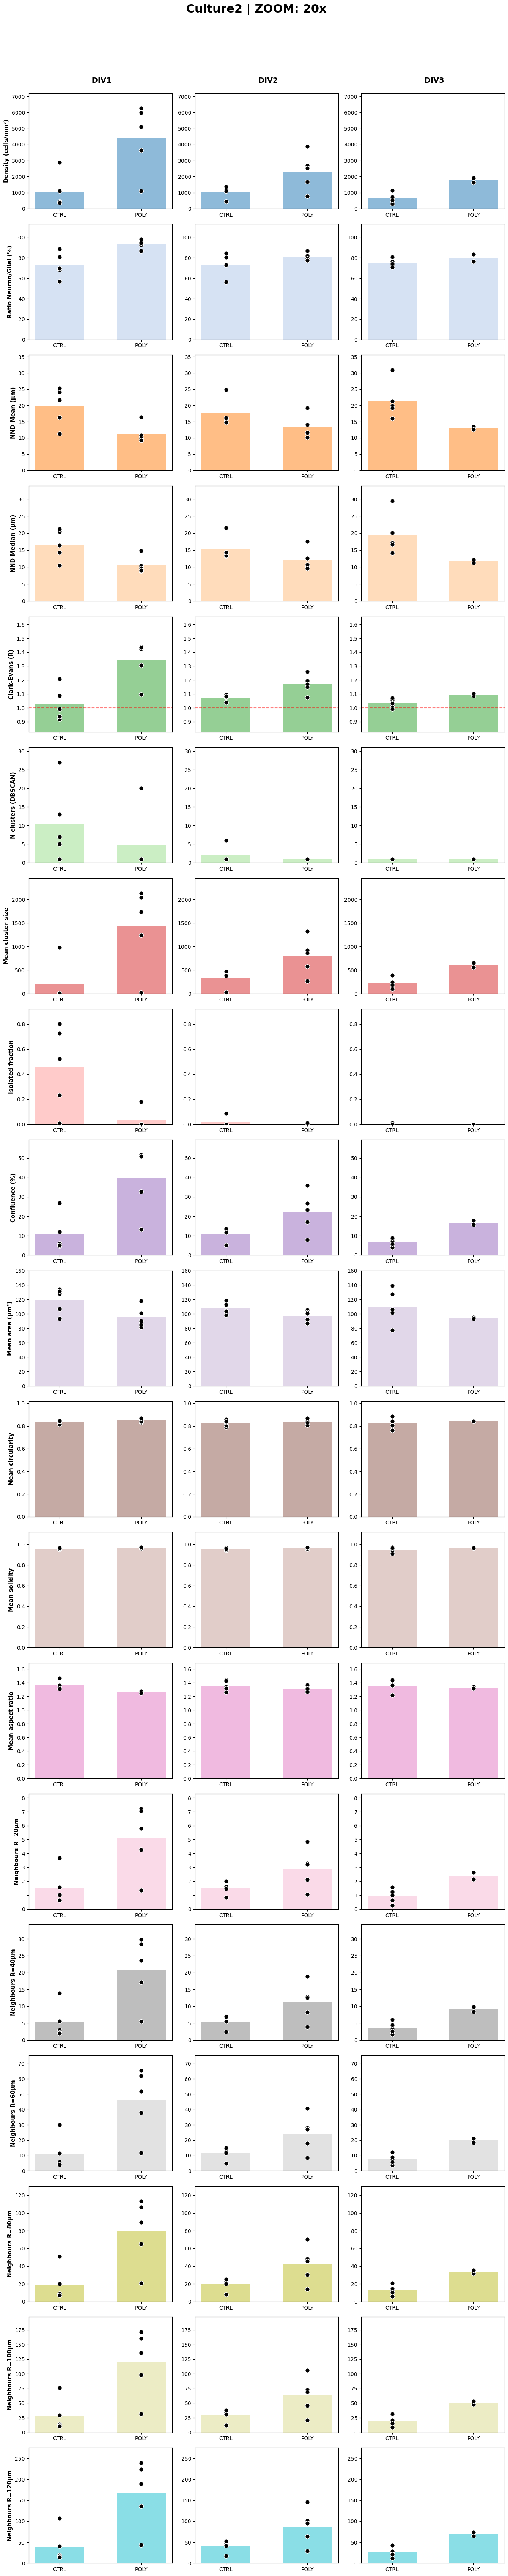

In [14]:
# %%
# PLOT (Culture > DIV > ZOOM)
# BARCHART + POINTS

# 1. Define all the metrics you want to plot dynamically
PLOT_METRICS = [
    ('density', 'Density (cells/mm²)'),
    ('ratio_neuron_glial', 'Ratio Neuron/Glial (%)'),
    ('nnd_mean', 'NND Mean (µm)'),
    ('nnd_median', 'NND Median (µm)'),
    ('clark_evans_r', 'Clark-Evans (R)'),
    ('n_clusters', 'N clusters (DBSCAN)'),
    ('mean_cluster_size', 'Mean cluster size'),
    ('frac_isolated', 'Isolated fraction'),
    ('confluence_pct', 'Confluence (%)'),
    ('mean_area_um2', 'Mean area (µm²)'),
    ('mean_circularity', 'Mean circularity'),
    ('mean_solidity', 'Mean solidity'),
    ('mean_aspect_ratio', 'Mean aspect ratio')
]
# Add neighbours metrics to the list
for R in RADIUS_UM:
    PLOT_METRICS.append((f'mean_neighbours_R{R}', f'Neighbours R={R}µm'))

n_rows = len(PLOT_METRICS)
cultures = sorted(df_results['culture'].unique())

for cult_id in cultures:
    df_cult = df_results[df_results['culture'] == cult_id]
    zooms = [z for z in ['10x', '20x', '40x'] if z in df_cult['zoom'].unique()]
    divs = sorted(df_cult['div'].unique()) 

    for zoom in zooms:
        df_zoom = df_cult[df_cult['zoom'] == zoom]
        fig, axes = plt.subplots(n_rows, len(divs), figsize=(4.5*len(divs), 3.5*n_rows), squeeze=False)

        for r_idx, (metric, title) in enumerate(PLOT_METRICS): 
            # Align y-axis for DIV comparisons
            all_values = df_zoom[metric].dropna()
            if not all_values.empty:
                y_max = all_values.max() * 1.15 # +15% margin at the top
                y_min = 0 if metric != 'clark_evans_r' else all_values.min() * 0.9 
            else:
                y_max, y_min = 1, 0

            for c_idx, div in enumerate(divs): 
                ax = axes[r_idx][c_idx] 
                df_plot = df_zoom[df_zoom['div'] == div] 
                
                ctrl_data = df_plot[df_plot['type'].str.lower() == 'control'][metric].dropna()
                poly_data = df_plot[df_plot['type'].str.lower() == 'pppy'][metric].dropna()
                
                # Plot for each
                means = [ctrl_data.mean() if not ctrl_data.empty else 0, 
                         poly_data.mean() if not poly_data.empty else 0]
                
                # Use a colormap for dynamic styling based on the row index
                color = plt.cm.tab20(r_idx % 20) 
                
                ax.bar([0, 1], means, color=color, alpha=0.5, width=0.6) 
                
                if not ctrl_data.empty:
                    ax.scatter([0] * len(ctrl_data), ctrl_data, color='black', edgecolor='white', s=70, zorder=3) 
                if not poly_data.empty:
                    ax.scatter([1] * len(poly_data), poly_data, color='black', edgecolor='white', s=70, zorder=3) 

                # Axes settings
                ax.set_ylim(y_min, y_max)
                ax.set_xticks([0, 1])
                ax.set_xticklabels(['CTRL', 'POLY'])

                # Titles and labels
                if c_idx == 0:
                    ax.set_ylabel(title, fontweight='bold', fontsize=11)
                
                if r_idx == 0:
                    ax.set_title(f" {div}", fontsize=14, fontweight='black', pad=20) 
                else:
                    ax.set_title("") 

                # Clark-Evans reference line
                if metric == 'clark_evans_r':
                    ax.axhline(y=1, color='red', linestyle='--', alpha=0.5)

        fig.suptitle(f" {cult_id} | ZOOM: {zoom}", fontsize=22, fontweight='black', y=1.02)
        plt.tight_layout()
        plt.show()

### Boxplots

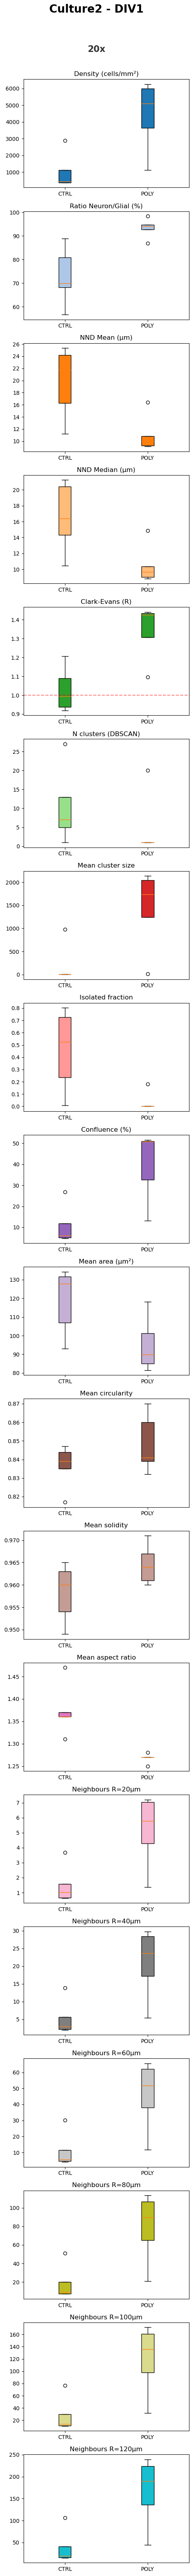

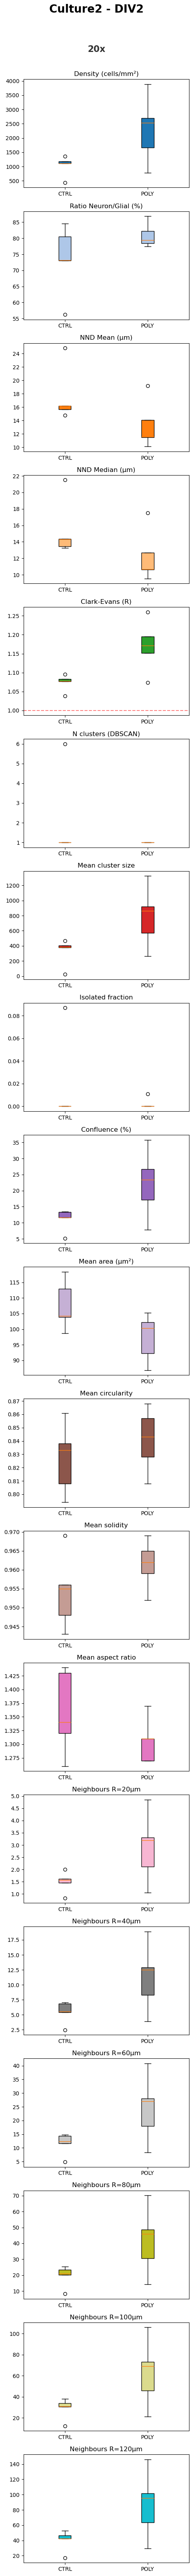

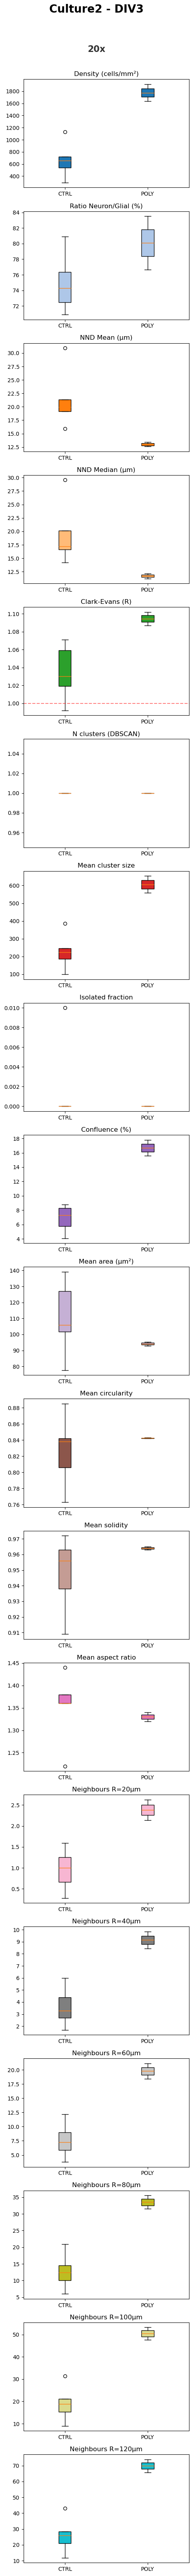

In [15]:
# %%
# PLOT (Culture > DIV > ZOOM)
# BOXPLOT

n_rows = len(PLOT_METRICS)
cultures = sorted(df_results['culture'].unique())

for cult_id in cultures:
    df_cult = df_results[df_results['culture'] == cult_id]
    divs = sorted(df_cult['div'].unique())
    
    for div in divs:
        df_div = df_cult[df_cult['div'] == div]
        zooms_present = [z for z in ['10x', '20x', '40x'] if z in df_div['zoom'].unique()]
        if not zooms_present: continue

        fig, axes = plt.subplots(n_rows, len(zooms_present), figsize=(5*len(zooms_present), 3.5*n_rows))
        
        if len(zooms_present) == 1:
            axes = np.atleast_2d(axes).T

        for i, zoom in enumerate(zooms_present):
            df_plot = df_div[df_div['zoom'] == zoom]
            ctrl = df_plot[df_plot['type'].str.lower() == 'control']
            poly = df_plot[df_plot['type'].str.lower() == 'pppy']
            
            tick_labels = ['CTRL', 'POLY']
            bp_kwargs = {'tick_labels': tick_labels, 'patch_artist': True}

            # Loop through all metrics dynamically
            for r_idx, (metric, title) in enumerate(PLOT_METRICS):
                ax = axes[r_idx][i]
                
                c_data = ctrl[metric].dropna()
                p_data = poly[metric].dropna()
                
                # Matplotlib boxplot needs lists, even empty ones
                plot_data = [c_data if not c_data.empty else [], 
                             p_data if not p_data.empty else []]
                
                # Fetch a dynamic color
                color = plt.cm.tab20(r_idx % 20)
                
                bplot = ax.boxplot(plot_data, **bp_kwargs)
                
                # Color the boxes
                for patch in bplot['boxes']:
                    patch.set_facecolor(color)
                
                ax.set_title(title, fontsize=12)
                
                # Clark-Evans reference line
                if metric == 'clark_evans_r':
                    ax.axhline(y=1, color='red', linestyle='--', alpha=0.5)

        zoom_str = " - ".join(zooms_present)
        fig.text(0.5, 0.98, f"{cult_id} - {div}", fontsize=20, fontweight='black', ha='center')
        fig.text(0.5, 0.965, f"{zoom_str}", fontsize=16, fontweight='bold', ha='center', color='#333333')
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

## Density map (KDE)

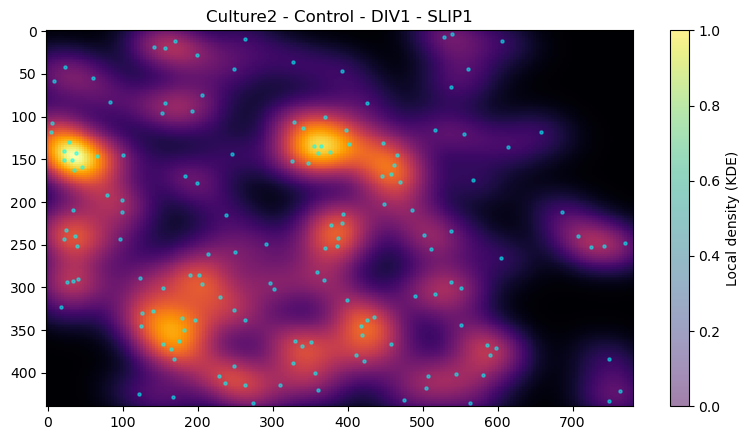

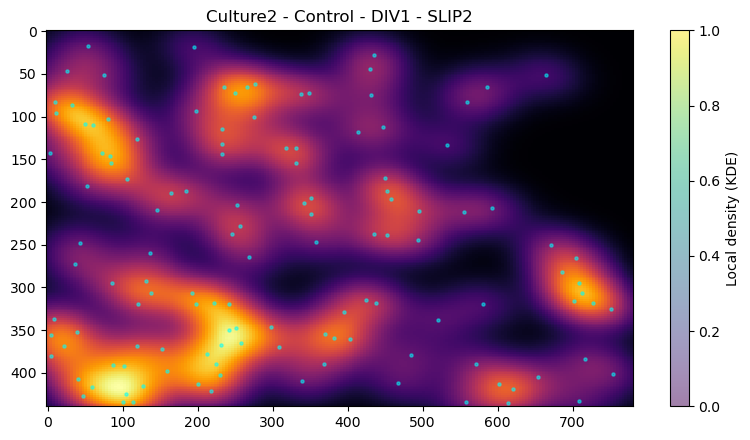

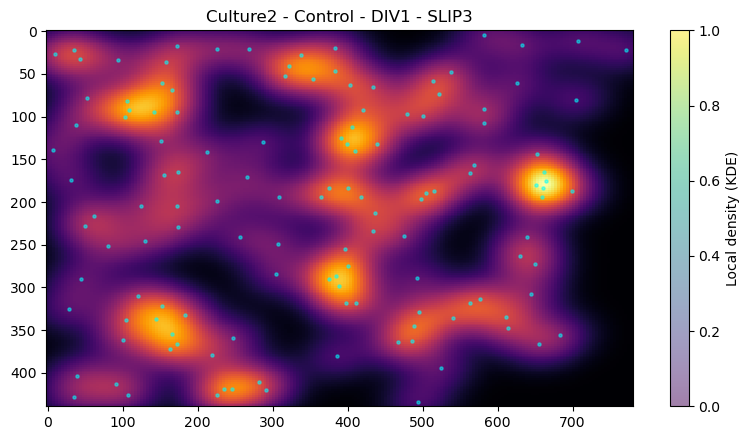

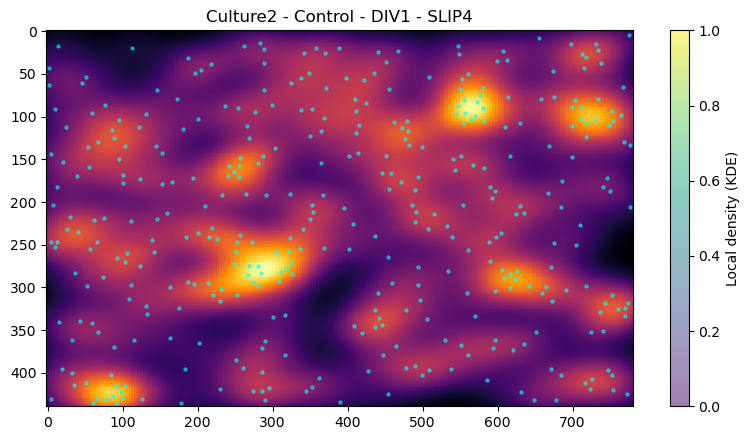

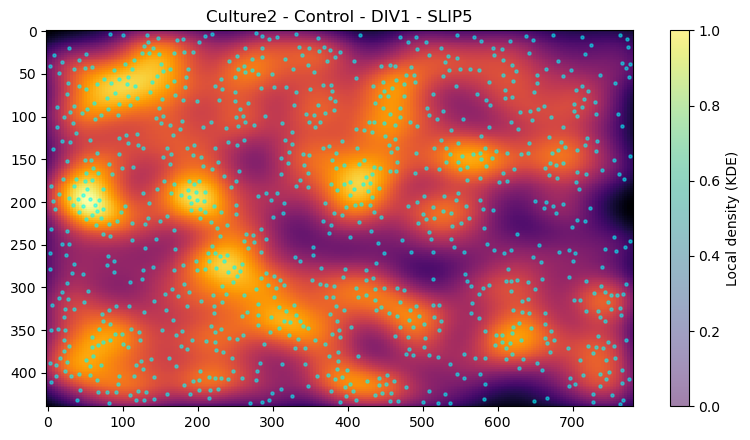

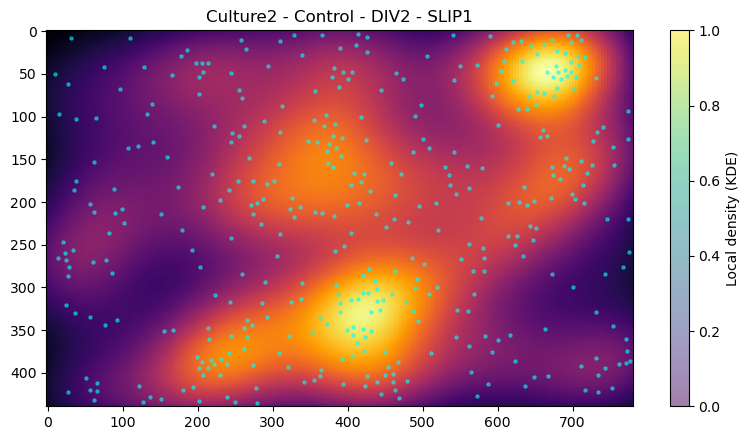

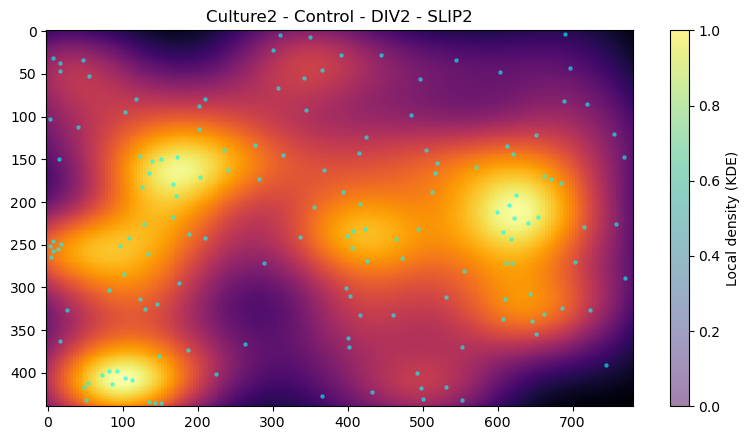

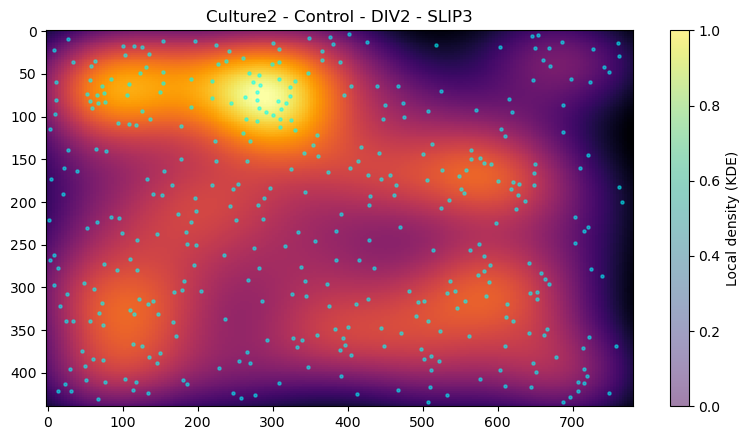

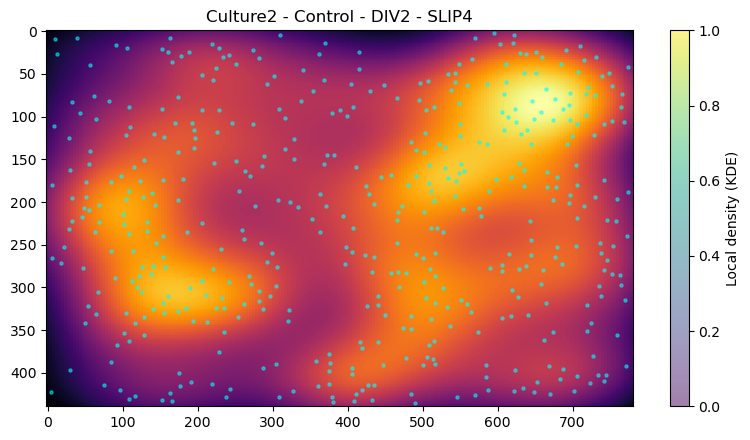

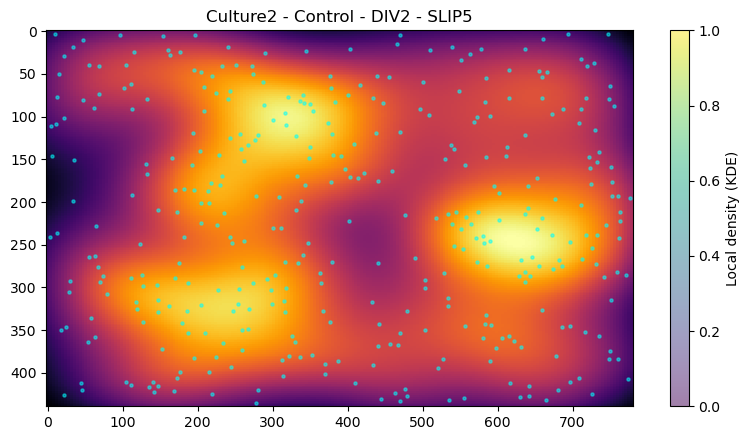

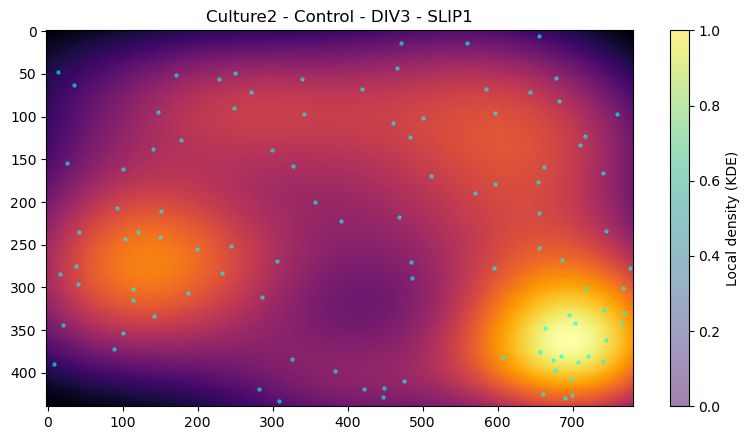

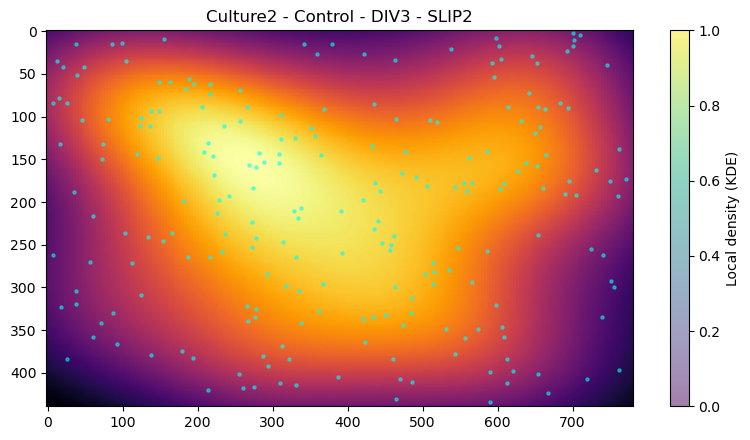

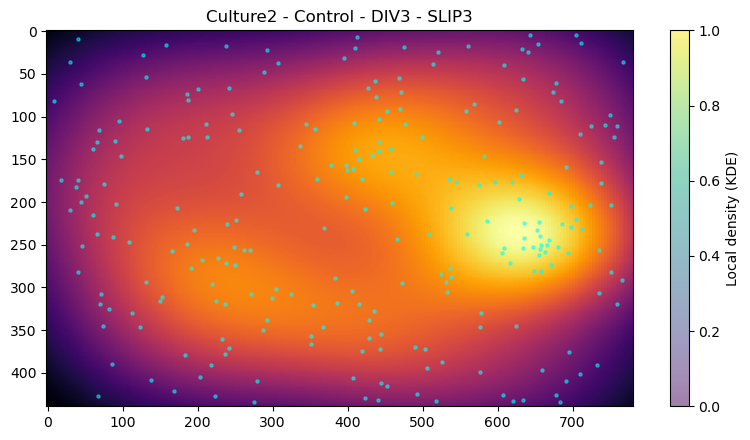

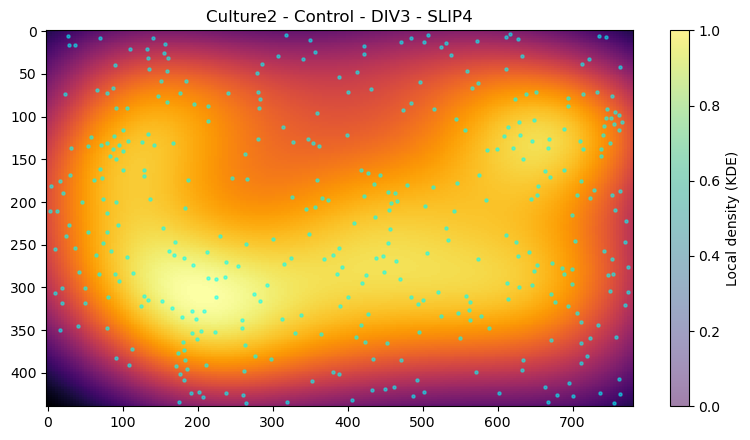

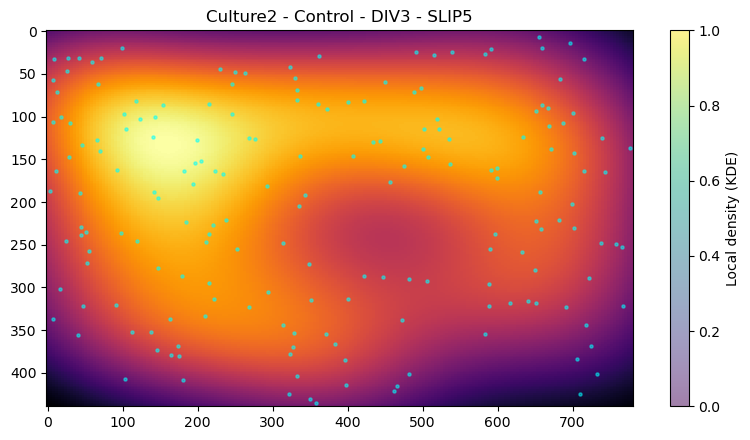

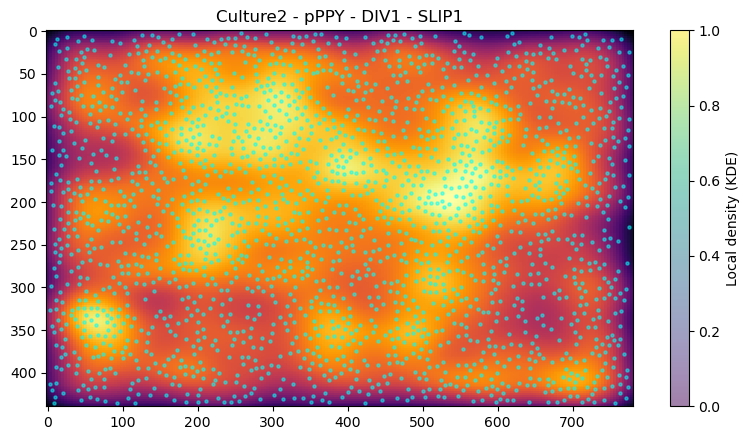

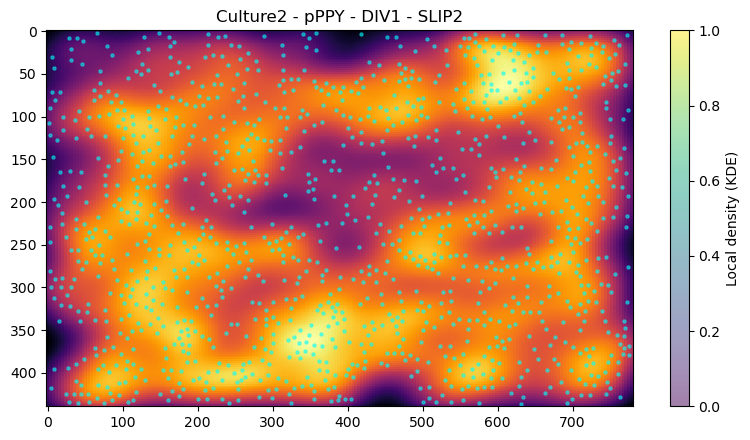

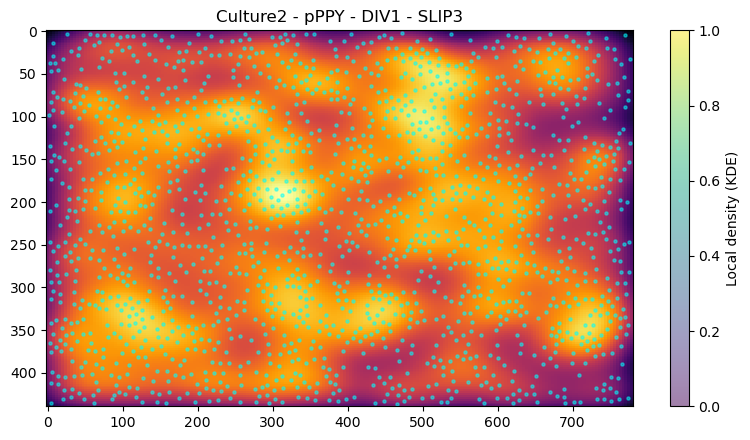

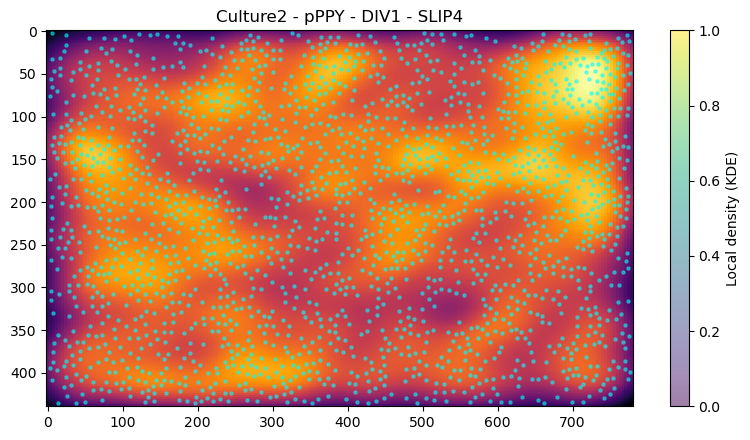

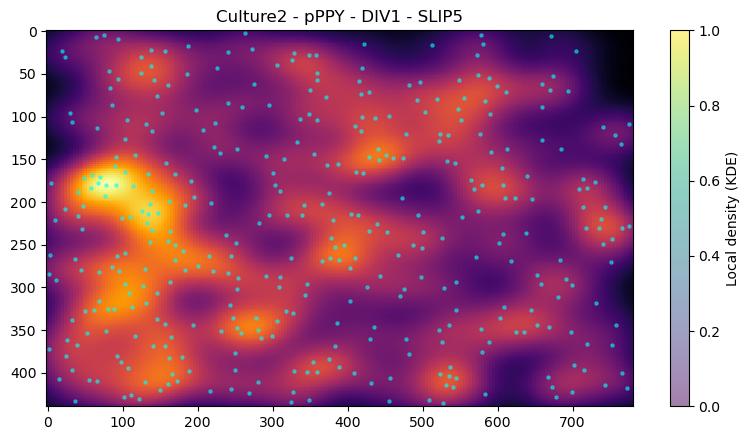

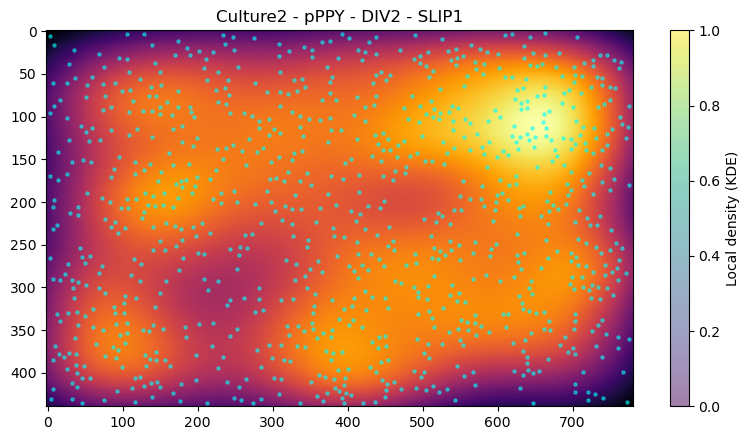

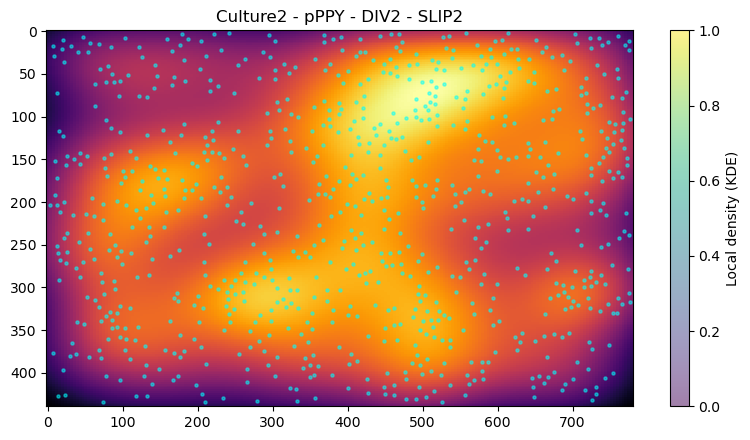

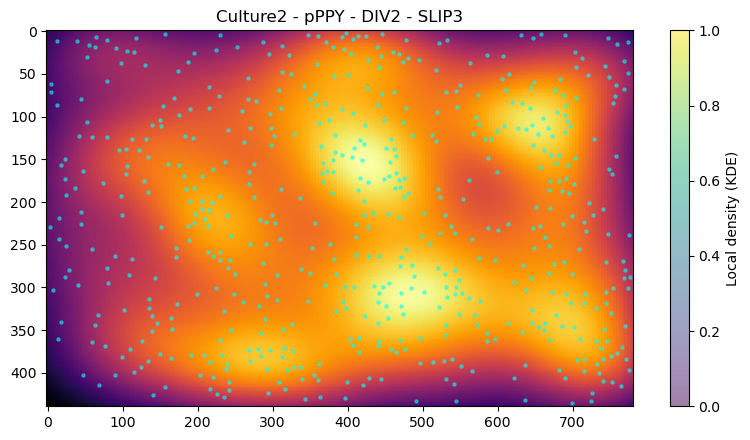

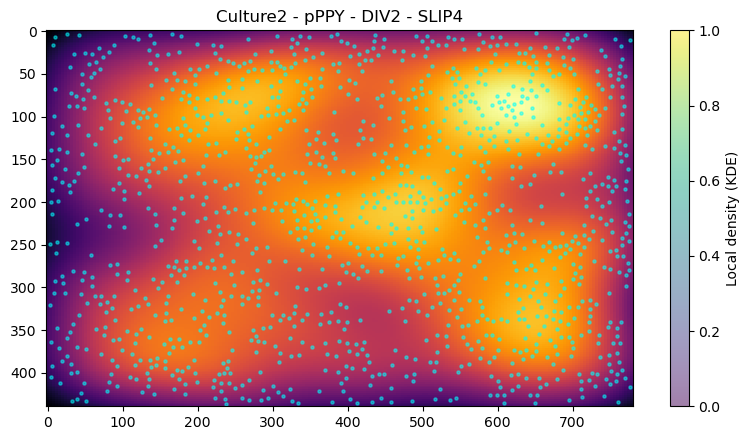

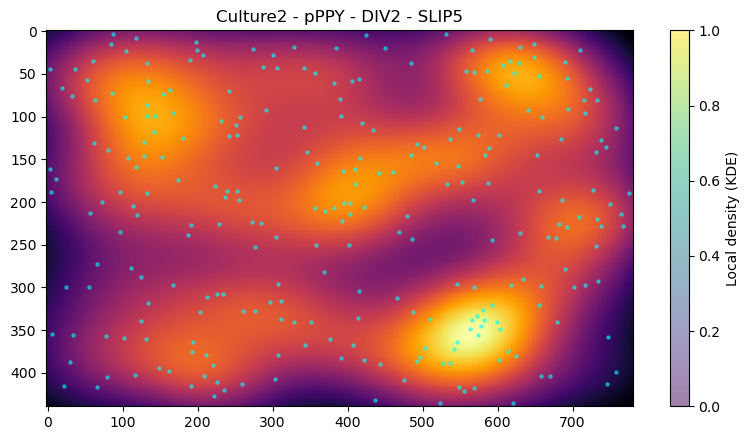

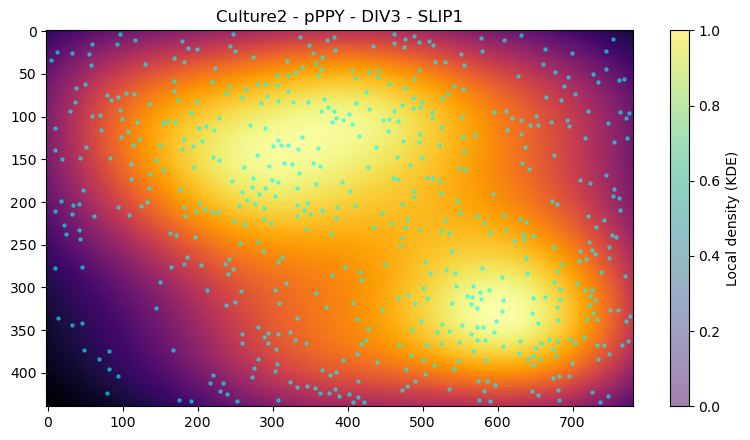

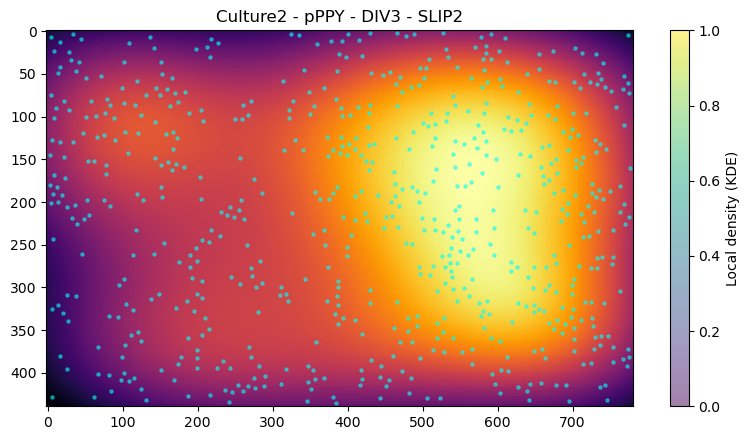

In [16]:
def compute_density_map(coords_um, width_um, height_um, bandwidth_um=NEURITE_LENGTH_UM.get(row['div'], 70), grid_res=200):
    x, y = coords_um[:, 0], coords_um[:, 1]
    kde = gaussian_kde(np.vstack([x, y]))
    kde.set_bandwidth(bw_method=bandwidth_um / coords_um.std())
    xi, yi = np.mgrid[0:width_um:grid_res*1j, 0:height_um:grid_res*1j]
    zi = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
    return xi, yi, zi

for _, row in df_data.iterrows():
    p = PARAMS[row['zoom']]
    um = p['um_by_px']
    width_um = p['image_width'] * um
    height_um = p['image_height'] * um

    df_img = pd.read_csv(row['csv_path'])
    df_img = df_img[df_img['status'] == 'somas']  
    coords_um = df_img[['x', 'y']].values * um

    if len(coords_um) < 2:
        continue  

    bandwidth = NEURITE_LENGTH_UM.get(row['div'], 70) 
    xi, yi, zi = compute_density_map(coords_um, width_um, height_um, bandwidth_um=bandwidth)

    plt.figure(figsize=(8, 4.5))
    plt.pcolormesh(xi, yi, zi, cmap='inferno', shading='auto')
    plt.scatter(coords_um[:, 0], coords_um[:, 1], s=5, color='cyan', alpha=0.5)
    plt.gca().invert_yaxis()
    plt.colorbar(label='Local density (KDE)')
    plt.title(f"{row['culture']} - {row['type']} - {row['div']} - {row['slip']}")
    plt.tight_layout()
    #plt.savefig(f"density_map_{row['culture']}_{row['type']}_{row['div']}_{row['slip']}.png") 
    plt.show()